# Statistics Foundations

## 2. Description (Solutions)

### 2.1 Per-capita GDP

The file `data/gdp_pcap.csv` contains observed or predicted per-capita GDP for countries around the world in various years. 

The per capita GDP is given in 2021 international dollar units. 

The data was originally downloaded from [here](https://www.gapminder.org/data/).

Load the data into a `pandas` dataframe.

*Hint*: use `DataFrame.head()` after loading to check that the top of the table is as expected.

In [1]:
import pandas as pd

gdp = pd.read_csv("../data/gdp_pcap.csv")
gdp.head()

,country,region,year,gdp_pp
0,Afghanistan,asia_west,1800,560.88817
1,Angola,africa_sub_saharan,1800,435.23259
2,Albania,europe_east,1800,547.53369
3,Andorra,europe_west,1800,1598.53128
4,UAE,asia_west,1800,1332.77712


Create a DataFrame containing only the data for the countries in the region `asia_east` in the year 2025.

*Hint*: 
You can create a boolean `Series` using an expression like 
`gdp['region'] == "east_asia_pacific"`.
You can use that boolean `Series` to select the rows that you want from the DataFrame using something like 
`gdp[gdp['region'] == "east_asia_pacific"]`.
You can combine boolean `Series` using the operators `&` (AND) and `|` (OR). 


In [2]:
asia_east_2025 = gdp[(gdp['region'] == "east_asia_pacific") & (gdp['year'] == 2025)]
asia_east_2025.head()

,country,region,year,gdp_pp
43433,Australia,east_asia_pacific,2025,61942.61476
43450,Brunei,east_asia_pacific,2025,82692.81626
43457,China,east_asia_pacific,2025,25504.91715
43482,Fiji,east_asia_pacific,2025,14765.58232
43484,"Micronesia, Fed. Sts.",east_asia_pacific,2025,3967.76263


Visualise the distribution of `gdp_pp` for this new dataset.

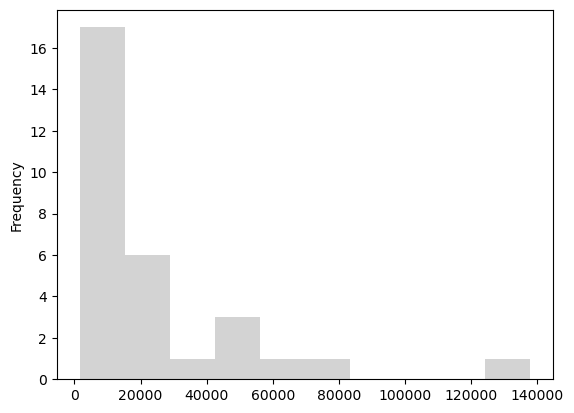

In [3]:
import matplotlib.pyplot as plt

asia_east_2025['gdp_pp'].plot.hist(color='lightgray')
plt.show()

Using appropriate statistics, how could you summarise this distribution?

In [4]:
# The distribution is highly skewed, so the mean and standard deviation 
# are not very meaningful. It would be better to quote the median and IQR:

gdp_pp_median = asia_east_2025['gdp_pp'].median()
gdp_pp_IQR = asia_east_2025['gdp_pp'].quantile(0.75) - \
    asia_east_2025['gdp_pp'].quantile(0.25)

print("Median per capita GDP =", int(gdp_pp_median.round()), "dollars.")
print("IQR of per capita GDP =", int(gdp_pp_IQR.round()), "dollars.")


Median per capita GDP = 12028 dollars.
IQR of per capita GDP = 19024 dollars.


Plot the GDP of India over the period 1950-2000.

*Hint*: use `Series.plot.line()`

In [5]:
india_1918_1939 = gdp[(gdp['country'] == "India") \
                      & (gdp['year'] >= 1918)\
                      & (gdp['year'] <= 1939)]

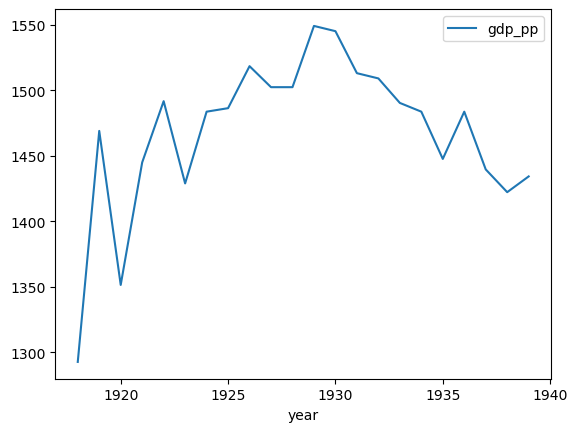

In [6]:
india_1918_1939.plot.line(x = 'year', y = 'gdp_pp')
plt.show()

Using appropriate statistics, how could you summarise this series?

In [7]:
# The mean and standard deviation can be used to give a central value and dispersion
# over this time range.

gdp_pp_mean = india_1918_1939['gdp_pp'].mean()
gdp_pp_sd = india_1918_1939['gdp_pp'].std()

print("Mean per capita GDP =", int(gdp_pp_mean.round()), "dollars.")
print("SD of per capita GDP =", int(gdp_pp_sd.round()), "dollars.")

Mean per capita GDP = 1468 dollars.
SD of per capita GDP = 59 dollars.


Use box plots to present the distributions of `gdp_pp` for the different regions in 2025, on a single figure.

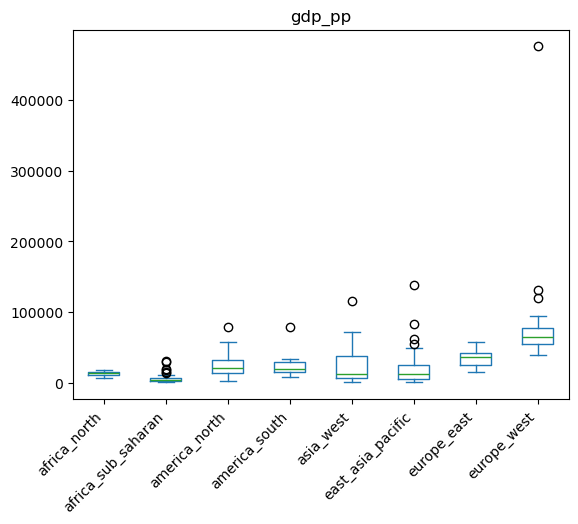

In [8]:
gdp[gdp['year'] == 2025][['gdp_pp','region']].plot.box(by='region')
plt.xticks(rotation=45, ha='right')
plt.show()

### 2.2 Liver cirrhosis

Load the liver cirrhosis dataset from `data/cirrhosis.csv`

Find the Pearson correlation between all pairs of quantitative features.

In [9]:
cirrhosis = pd.read_csv('../data/cirrhosis.csv')

In [10]:
quantitative_features = ['Age',
                         'Bilirubin',
                         'Cholesterol',
                         'Albumin',
                         'Copper',
                         'Alk_Phos',
                         'SGOT',
                         'Triglicerides',
                         'Platelets',
                         'Prothrombin']

cirrhosis[quantitative_features].corr()

,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Triglicerides,Platelets,Prothrombin
Age,1.000000,0.006288,-0.157620,-0.182836,0.061549,-0.047247,-0.149869,0.022065,-0.158195,0.115933
Bilirubin,0.006288,1.000000,0.397129,-0.318619,0.456918,0.116984,0.441730,0.436748,-0.024845,0.313184
Cholesterol,-0.157620,0.397129,1.000000,-0.069733,0.126115,0.149473,0.353246,0.276830,0.191710,-0.030811
Albumin,-0.182836,-0.318619,-0.069733,1.000000,-0.264771,-0.101456,-0.220047,-0.103417,0.167703,-0.207897
Copper,0.061549,0.456918,0.126115,-0.264771,1.000000,0.187357,0.293829,0.279852,-0.064403,0.218224
Alk_Phos,-0.047247,0.116984,0.149473,-0.101456,0.187357,1.000000,0.112217,0.180082,0.143733,0.089384
SGOT,-0.149869,0.441730,0.353246,-0.220047,0.293829,0.112217,1.000000,0.126119,-0.120147,0.112174
Triglicerides,0.022065,0.436748,0.276830,-0.103417,0.279852,0.180082,0.126119,1.000000,0.103212,0.020122
Platelets,-0.158195,-0.024845,0.191710,0.167703,-0.064403,0.143733,-0.120147,0.103212,1.000000,-0.191110
Prothrombin,0.115933,0.313184,-0.030811,-0.207897,0.218224,0.089384,0.112174,0.020122,-0.191110,1.000000


Create a scatter plot for the pair of variables that is most strongly correlated.

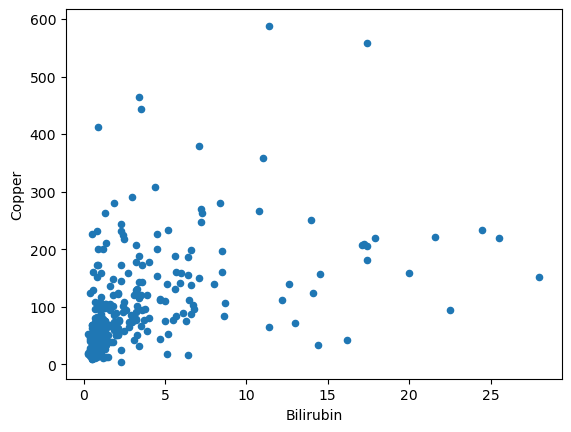

In [11]:
cirrhosis.plot.scatter('Bilirubin','Copper')
plt.show()

Examine the behaviour if you take logs of both these variables instead of using the raw values.
*Hint*: Use the `numpy` function `log10` on the `Series` objects.

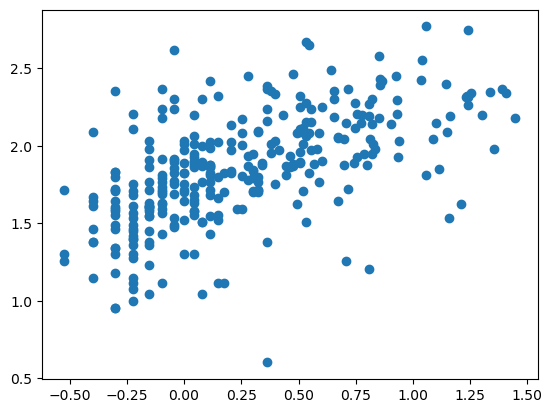

In [12]:
import numpy as np

# need to drop rows with missing values in these variables
df = cirrhosis[['Bilirubin', 'Copper']].dropna()
bilirubin_log10 = np.log10(df['Bilirubin'])
copper_log10 = np.log10(df['Copper'])

plt.scatter(bilirubin_log10, copper_log10)
plt.show()

In [13]:
from scipy.stats import pearsonr
print(round(pearsonr(bilirubin_log10, copper_log10).correlation, 3))

# The correlation is much stronger in the log-transformed data

0.586


### 1.2 MAGIC Gamma Telescope

Load the data from `data/magic04.csv`.

Calculate the skewness and excess kurtosis for each of the variables, for the gamma ray signal (class `g`).

In [14]:
magic = pd.read_csv('../data/magic04.csv')

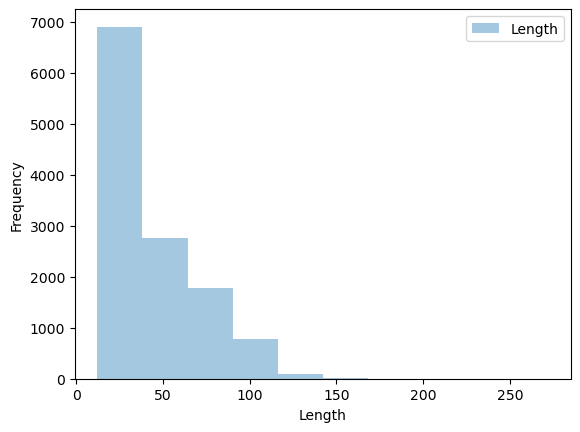

Skewness of Length = 1.236569653435184
Excess kurtosis of Length = 1.6398420189344263


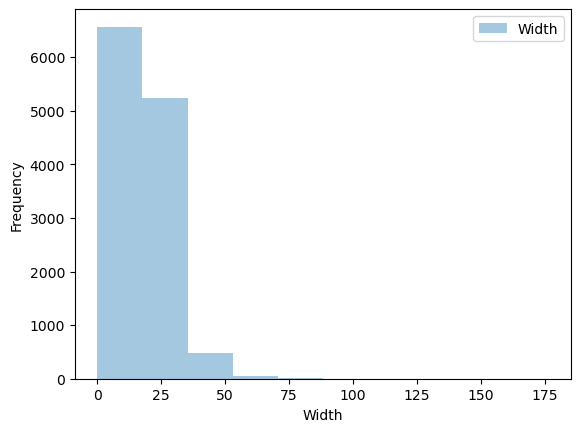

Skewness of Width = 2.4791543022714992
Excess kurtosis of Width = 20.72977926890029


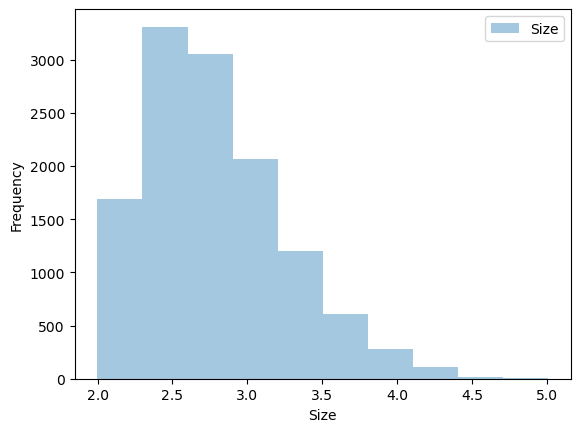

Skewness of Size = 0.819160712115575
Excess kurtosis of Size = 0.45335362804789314


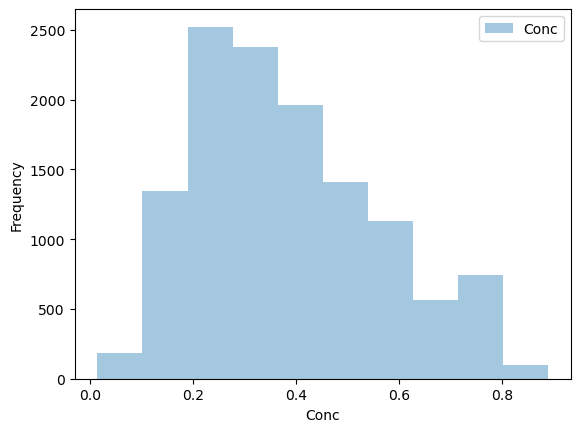

Skewness of Conc = 0.5713529091223833
Excess kurtosis of Conc = -0.47179791777701174


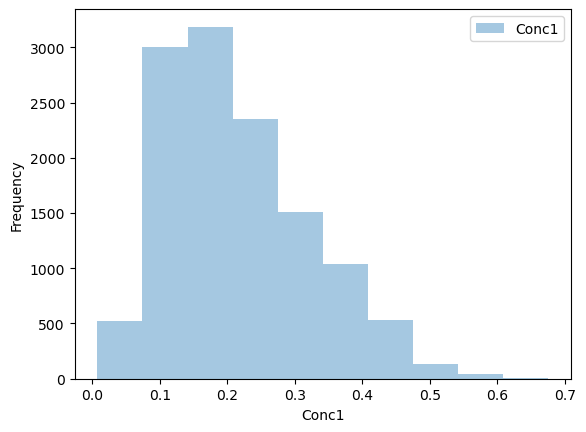

Skewness of Conc1 = 0.7398121343299104
Excess kurtosis of Conc1 = 0.061799040789834336


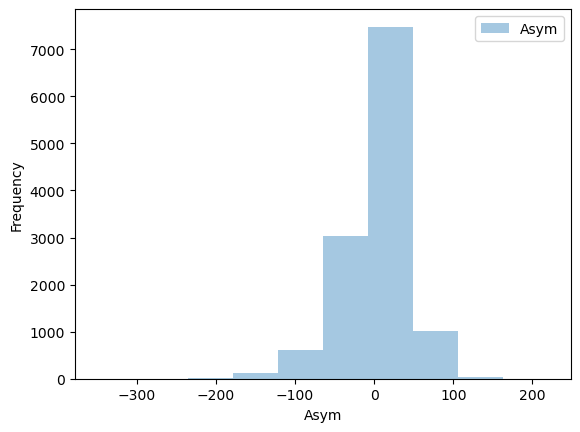

Skewness of Asym = -0.9169317571422613
Excess kurtosis of Asym = 3.429312482627389


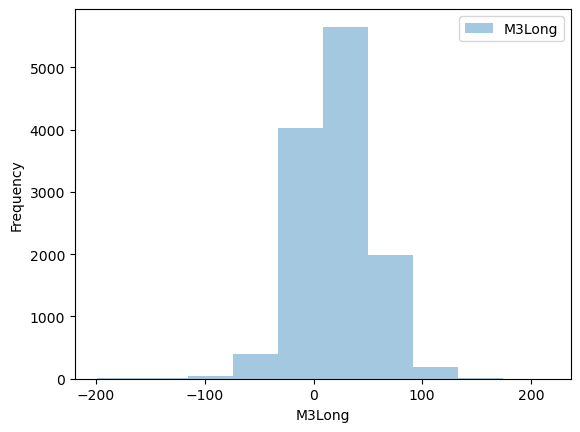

Skewness of M3Long = 0.14050754253388886
Excess kurtosis of M3Long = 0.9756561667533021


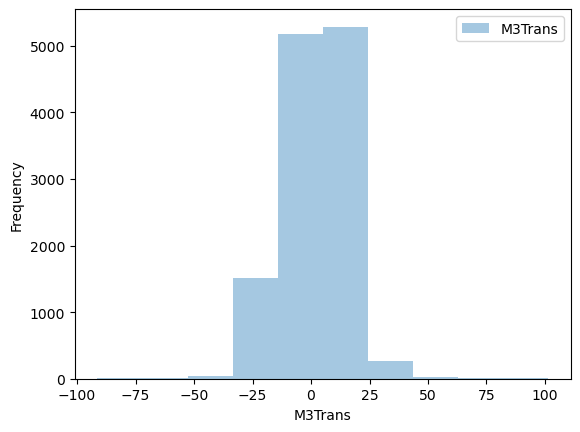

Skewness of M3Trans = 0.08138937835896497
Excess kurtosis of M3Trans = 1.2509571068134289


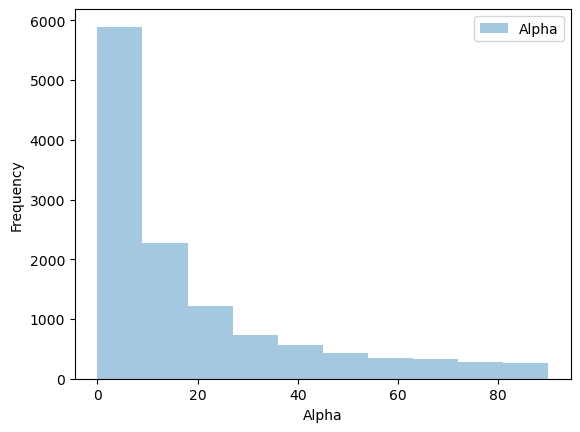

Skewness of Alpha = 1.548851824442515
Excess kurtosis of Alpha = 1.5630658655956298


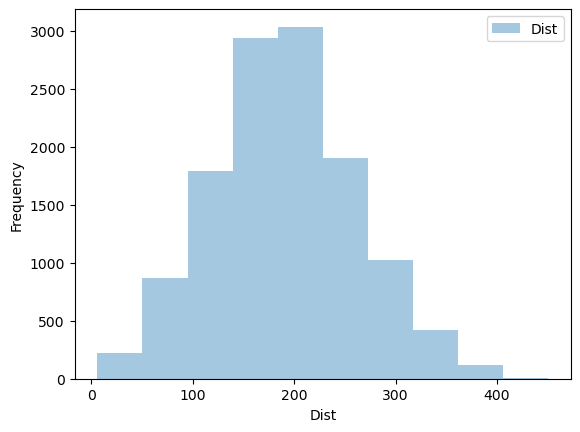

Skewness of Dist = 0.19447621450874444
Excess kurtosis of Dist = -0.11670991735917902


In [15]:
from scipy.stats import skew, kurtosis

# discarding the last column, which is the class
for f in magic.columns[:-1]:
    data = magic[magic['class'] == 'g'][f]
    data.plot.hist(alpha=0.4, 
                                            xlabel=f,
                                            legend=True)
    plt.show()
    print("Skewness of", f, "=", skew(data))
    print("Excess kurtosis of", f, "=", kurtosis(data))
 


Which of these variables appears to be closest to a normal distribution?

In [16]:
# Dist has both skewness and kurtosis close to zero, so the plot resembles a normal distribution.